# Notebook 05: Student-t Mixture Model (SMM)

In this notebook, we try a heavier-tailed alternative to Gaussian mixtures: the **Student-t distribution**.

The key idea is that Student-t components can downweight far-away points automatically through an auxiliary weight $u_{ik}$. So unusual digits do not pull the cluster centers too hard during EM.

**Steps:**
1. Load the preprocessed PCA dataset.
2. Implement the Student-t EM algorithm with diagonal covariance.
3. Train the model using the same $K=25$ setup as the other PCA-based models.
4. Evaluate using Purity/Accuracy, ARI, NMI, and plot the Confusion Matrix.
5. Generate new handwritten digits using `np.random.standard_t`.

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
from scipy.stats import mode
from scipy.special import digamma, gammaln, logsumexp
from scipy.optimize import brentq
from tqdm import trange
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, accuracy_score, confusion_matrix

os.makedirs('images/studentt', exist_ok=True)

# Load the full 70k processed data
X_pca = np.load('data/X_pca.npy')
y = np.load('data/y_labels.npy')

with open('data/pca_model.pkl', 'rb') as f:
    pca = pickle.load(f)

print(f"Loaded X_pca shape: {X_pca.shape}")
print(f"Loaded labels shape: {y.shape}")

Loaded X_pca shape: (70000, 50)
Loaded labels shape: (70000,)


### Step 1: The Student-t Expectation-Maximization (EM) Algorithm

There is no direct Student-t mixture in our setup, so we code EM from scratch with per-component $\nu_k$.

In [5]:
class StudentTMixtureModel:
    def __init__(self, n_components=25, max_iter=50, tol=1e-4, verbose=True):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.verbose = verbose

    def _student_t_log_pdf(self, X, k):
        N, D = X.shape
        sigma2_k = self.sigma2[k]
        mu_k = self.mu[k]
        nu_k = self.nu[k]

        diff = X - mu_k
        delta = np.sum((diff ** 2) / (sigma2_k + 1e-10), axis=1)

        log_det_term = np.sum(np.log(np.pi * nu_k * (sigma2_k + 1e-10)))
        log_norm = gammaln((nu_k + D) / 2.0) - gammaln(nu_k / 2.0) - 0.5 * log_det_term
        log_kernel = -((nu_k + D) / 2.0) * np.log1p(delta / (nu_k + 1e-10))

        log_pdf = log_norm + log_kernel
        u_ik = (nu_k + D) / (nu_k + delta + 1e-10)
        return log_pdf, u_ik

    def _e_step(self, X):
        N, _ = X.shape
        log_resp = np.zeros((N, self.K))
        u = np.zeros((N, self.K))

        for k in range(self.K):
            log_pdf_k, u_k = self._student_t_log_pdf(X, k)
            log_resp[:, k] = np.log(self.pi[k] + 1e-10) + log_pdf_k
            u[:, k] = u_k

        log_norm = logsumexp(log_resp, axis=1, keepdims=True)
        resp = np.exp(log_resp - log_norm)
        log_likelihood = np.sum(log_norm)
        return resp, u, log_likelihood

    def _update_nu(self, resp, u, D):
        Nk = resp.sum(axis=0) + 1e-10

        for k in range(self.K):
            c_k = np.sum(resp[:, k] * (np.log(u[:, k] + 1e-10) - u[:, k])) / Nk[k]

            def f(nu):
                return (
                    -digamma(nu / 2.0)
                    + np.log(nu / 2.0)
                    + 1.0
                    + c_k
                    + digamma((nu + D) / 2.0)
                    - np.log((nu + D) / 2.0)
                )

            low, high = 0.1, 100.0
            f_low, f_high = f(low), f(high)
            if np.isfinite(f_low) and np.isfinite(f_high) and f_low * f_high < 0:
                self.nu[k] = brentq(f, low, high)
            else:
                self.nu[k] = np.clip(self.nu[k], low, high)

    def _m_step(self, X, resp, u):
        N, D = X.shape
        Nk = resp.sum(axis=0) + 1e-10
        self.pi = Nk / N

        ru = resp * u
        for k in range(self.K):
            denom = np.sum(ru[:, k]) + 1e-10
            self.mu[k] = np.sum(ru[:, k][:, None] * X, axis=0) / denom

            sq = (X - self.mu[k]) ** 2
            self.sigma2[k] = np.sum(ru[:, k][:, None] * sq, axis=0) / Nk[k]
            self.sigma2[k] = np.clip(self.sigma2[k], 1e-4, None)

        self._update_nu(resp, u, D)

    def fit(self, X):
        N, D = X.shape
        # Smart initialization using KMeans
        km = KMeans(n_clusters=self.K, init='k-means++', n_init=10).fit(X)
        self.mu = km.cluster_centers_
        self.sigma2 = np.ones((self.K, D))
        self.pi = np.ones(self.K) / self.K
        self.nu = np.ones(self.K) * 10.0
        self.loss_history = []
        self.nu_history = []

        progress = trange(self.max_iter, desc="Training SMM", leave=True)
        for i in progress:
            resp, u, log_likelihood = self._e_step(X)
            self._m_step(X, resp, u)

            self.loss_history.append(log_likelihood)
            self.nu_history.append(np.mean(self.nu))

            if self.verbose:
                progress.set_description(f"Iter {i+1} | LogL: {log_likelihood:.2f} | avg nu: {np.mean(self.nu):.2f}")

            if len(self.loss_history) > 1 and np.abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                print(f"\nConverged at iteration {i+1}")
                break

    def predict(self, X):
        log_resp = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            log_pdf_k, _ = self._student_t_log_pdf(X, k)
            log_resp[:, k] = np.log(self.pi[k] + 1e-10) + log_pdf_k
        return np.argmax(log_resp, axis=1)

    def sample(self, n_samples=10):
        samples = []
        component_ids = np.random.choice(self.K, size=n_samples, p=self.pi)
        for k in component_ids:
            z = np.random.standard_t(df=self.nu[k], size=self.mu[k].shape)
            x = self.mu[k] + np.sqrt(self.sigma2[k]) * z
            samples.append(x)
        return np.array(samples)

### Step 2: Training
We use $K=25$ here as well, so this stays directly comparable with GMM and LMM.

Iter 50 | LogL: -3431545.77 | avg nu: 49.70: 100%|██████████| 50/50 [02:13<00:00,  2.67s/it]


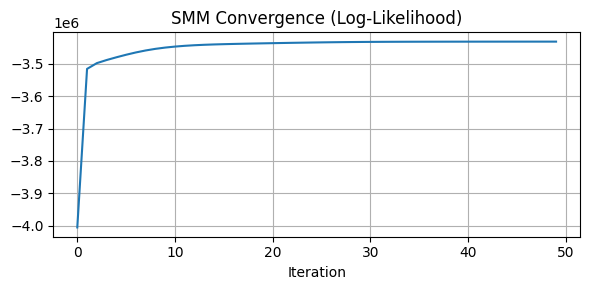

In [6]:
OPTIMAL_K = 25

smm = StudentTMixtureModel(n_components=OPTIMAL_K, max_iter=50, verbose=True)
smm.fit(X_pca)

clusters = smm.predict(X_pca)

# Plot the Log-Likelihood curve to prove convergence
plt.figure(figsize=(6, 3))
plt.plot(smm.loss_history)
plt.title("SMM Convergence (Log-Likelihood)")
plt.xlabel("Iteration")
plt.grid(True)
plt.tight_layout()
plt.savefig('images/studentt/studentt_convergence.png', dpi=200, bbox_inches='tight')
plt.show()

### Step 3: Evaluation


--- SMM Evaluation Metrics (K=25) ---
Mapped Accuracy (Purity): 74.14%
ARI: 0.3275
NMI: 0.5721
Average nu: 49.6975



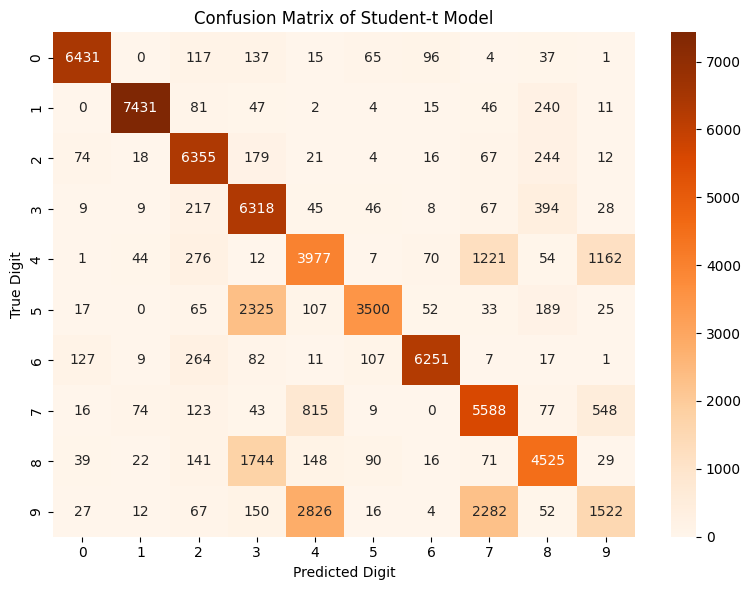

In [7]:
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

def map_clusters_to_digits(y_true, y_pred, n_clusters):
    labels = np.zeros_like(y_pred)
    for cluster in range(n_clusters):
        mask = (y_pred == cluster)
        if np.any(mask):
            labels[mask] = mode(y_true[mask], keepdims=False).mode
    return labels

y_pred_mapped = map_clusters_to_digits(y, clusters, n_clusters=OPTIMAL_K)
acc = accuracy_score(y, y_pred_mapped)

print(f"--- SMM Evaluation Metrics (K={OPTIMAL_K}) ---")
print(f"Mapped Accuracy (Purity): {acc * 100:.2f}%")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Average nu: {np.mean(smm.nu):.4f}\n")

cm = confusion_matrix(y, y_pred_mapped, labels=range(10))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.title('Confusion Matrix of Student-t Model')
plt.tight_layout()
plt.savefig('images/studentt/studentt_confusion.png', dpi=200, bbox_inches='tight')
plt.show()

metrics = {'Accuracy': acc, 'ARI': ari, 'NMI': nmi, 'avg_nu': float(np.mean(smm.nu))}
with open('data/smm_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

### Step 4: Generative Sampling
Now we sample new PCA points from the learned Student-t components and invert PCA back to image space.

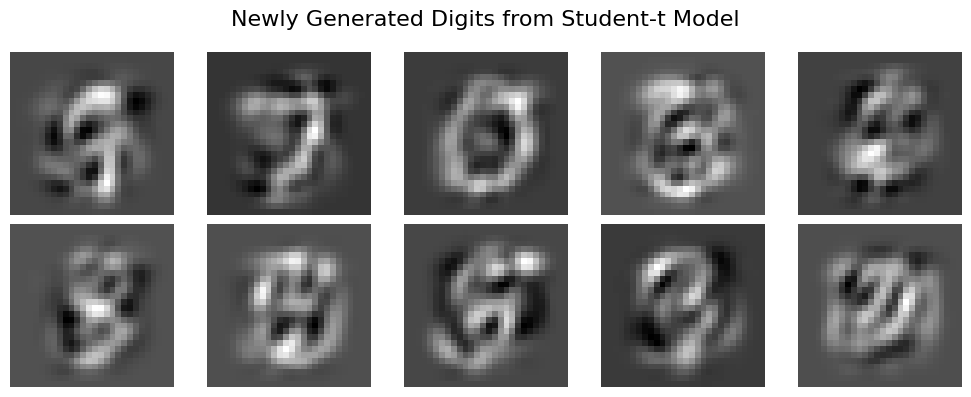

In [8]:
# 1. Sample 10 new data points from the learned Student-t distributions
new_pca_samples = smm.sample(n_samples=10)

# 2. Uncompress from 50 dims back to 784 dims
generated_digits_flat = pca.inverse_transform(new_pca_samples)

# 3. Plot the generated digits
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Newly Generated Digits from Student-t Model", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    img = generated_digits_flat[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig('images/studentt/studentt_samples.png', dpi=200, bbox_inches='tight')
plt.show()

# Save the fully uncompressed 784-dimensional generated images
samples = generated_digits_flat
np.save('data/smm_samples.npy', samples)